# Human lung cancer preprocess

Prepare the data for training.


## Settings


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

scanvi_train_kwargs = {"accelerator": "gpu", "devices": 1, "enable_progress_bar": False}
from pathlib import Path
import sys
import yaml

DATASET = "LUAD"
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "human_lung_cancer"
REPO_ROOT = EXPERIMENT_DIR.parents[1]

with (EXPERIMENT_DIR / "config.yaml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

def experiment_path(value):
    path = Path(value).expanduser()
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
SOURCE_ADATA = DATA_ROOT / "source.h5ad"
SCANVI_DIR.mkdir(parents=True, exist_ok=True)


from _shared.preprocess_plots import annotation_palette, sample_panels, alignment_overlay, embedding_panels


## Prepare data


In [2]:
import anndata as ad
import numpy as np
import scanpy as sc
import scvi

if not SOURCE_ADATA.is_file():
    raise FileNotFoundError(f"Missing linked source AnnData: {SOURCE_ADATA}")

adata = ad.read_h5ad(SOURCE_ADATA)
required_obs = {"status", "_clone_s"}
missing_obs = sorted(required_obs - set(adata.obs.columns))
if missing_obs:
    raise KeyError(f"Source AnnData is missing obs fields: {missing_obs}")
if "counts" not in adata.layers:
    raise KeyError("Source AnnData is missing adata.layers['counts']")
if "spatial" not in adata.obsm:
    raise KeyError("Source AnnData is missing adata.obsm['spatial']")

adata.obs["status"] = adata.obs["status"].astype(str).astype("category")
adata.obs["_clone_s"] = adata.obs["_clone_s"].astype(str).astype("category")
adata


AnnData object with n_obs × n_vars = 4280 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample_id', 'condition', 'patient', 'status', 'clone', 'tissue_need', '_sample_name', '_clone_s', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types'
    uns: '_clone_s_colors', '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'status_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'spatial_aligned'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Train scanVI


In [3]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    labels_key="_clone_s",
    unlabeled_category="Unknown",
    batch_key="status",
)
model = scvi.model.SCANVI(adata)
model.train(**scanvi_train_kwargs)


INFO     Training for 400 epochs.                                                                                  


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=207` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=400` reached.


## Spatial alignment


In [4]:
from stvirtual.models import uot_alignment_trans as alignment

LATENT_KEY = CONFIG.get("latent_key", "X_scanVI")
adata.obsm[LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=LATENT_KEY)
sc.tl.umap(adata)

source_mask = adata.obs["status"].astype(str).to_numpy() == "AAH"
reference_mask = adata.obs["status"].astype(str).to_numpy() == "LUAD"
if not source_mask.any() or not reference_mask.any():
    raise ValueError("Both AAH and LUAD observations are required for coordinate alignment")

spatial = np.asarray(adata.obsm["spatial"][:, :2], dtype=np.float64)
X_src = spatial[source_mask]
X_ref = spatial[reference_mask]
spatial_all = np.vstack([X_src, X_ref])
spatial_mean = spatial_all.mean(axis=0, keepdims=True)
spatial_std = spatial_all.std(axis=0, keepdims=True) + 1e-8
X_src_normalized = (X_src - spatial_mean) / spatial_std
X_ref_normalized = (X_ref - spatial_mean) / spatial_std

features = np.asarray(adata.obsm["X_umap"], dtype=np.float64)
F_src = features[source_mask]
F_ref = features[reference_mask]
feature_all = np.vstack([F_src, F_ref])
feature_min = feature_all.min(axis=0, keepdims=True)
feature_range = np.maximum(feature_all.max(axis=0, keepdims=True) - feature_min, 1e-8)
F_src = (F_src - feature_min) / feature_range
F_ref = (F_ref - feature_min) / feature_range

labels = adata.obs["_clone_s"].astype(str).to_numpy()
X_src_aligned_normalized, alignment_info = alignment.register_slice_to_ref_by_features(
    X_src_normalized,
    X_ref_normalized,
    F_src,
    F_ref,
    ann_src=labels[source_mask],
    ann_ref=labels[reference_mask],
    k_feat=32,
    match_mode="soft",
    alpha_xy=1.0,
    beta_feat=3.0,
    tau=0.8,
    seed=2025,
    verbose=True,
)
X_src_aligned = X_src_aligned_normalized * spatial_std + spatial_mean

spatial_aligned = spatial.copy()
spatial_aligned[source_mask] = X_src_aligned
adata.obs["cx_aligned"] = spatial_aligned[:, 0]
adata.obs["cy_aligned"] = spatial_aligned[:, 1]
adata.obsm["spatial_aligned"] = spatial_aligned.astype(np.float32)

print(f"Aligned {source_mask.sum()} AAH spots to {reference_mask.sum()} LUAD reference spots")


UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.6313, reg=0.0717, score=0.6313, th=-3.02, trial=1]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.6029, reg=0.143, score=0.6029, th=-3.05, trial=2] 

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5684, reg=0.287, score=0.5684, th=-3.08, trial=3]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5684, reg=0.0717, score=0.6313, th=-3.02, trial=4]

...

ICP refine (feat):  80%|████████  | 32/40 [00:00<00:00, 69.98it/s, cls=1, med=0.3471, p90=0.8598, th=-2.52, tx=-2.06, ty=-0.364]

ICP refine (feat):  80%|████████  | 32/40 [00:00<00:00, 69.98it/s, cls=1, med=0.3471, p90=0.8598, th=-2.52, tx=-2.06, ty=-0.364]

ICP refine (feat): 100%|██████████| 40/40 [00:00<00:00, 69.48it/s, cls=1, med=0.3471, p90=0.8598, th=-2.52, tx=-2.06, ty=-0.364]

ICP refine (feat): 100%|██████████| 40/40 [00:00<00:00, 70.58it/s, cls=1, med=0.3471, p90=0.8598, th=-2.52, tx=-2.06, ty=-0.364]

Aligned 806 AAH spots to 3474 LUAD reference spots


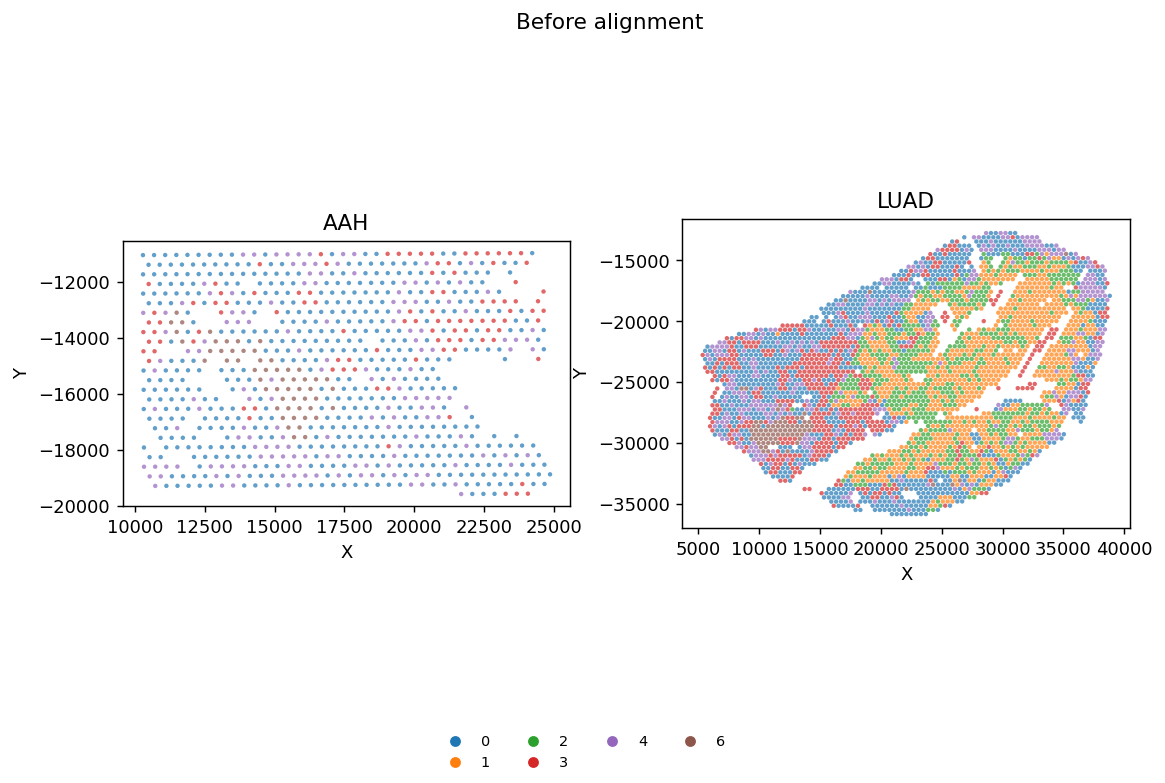

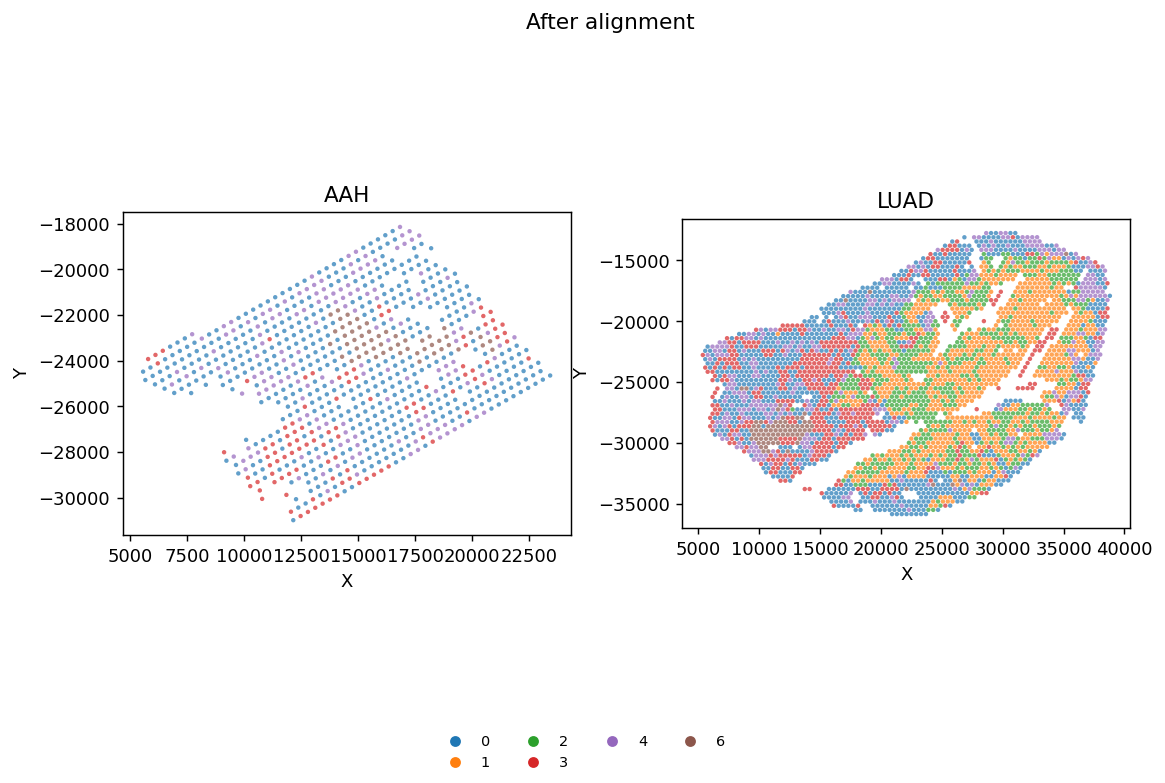

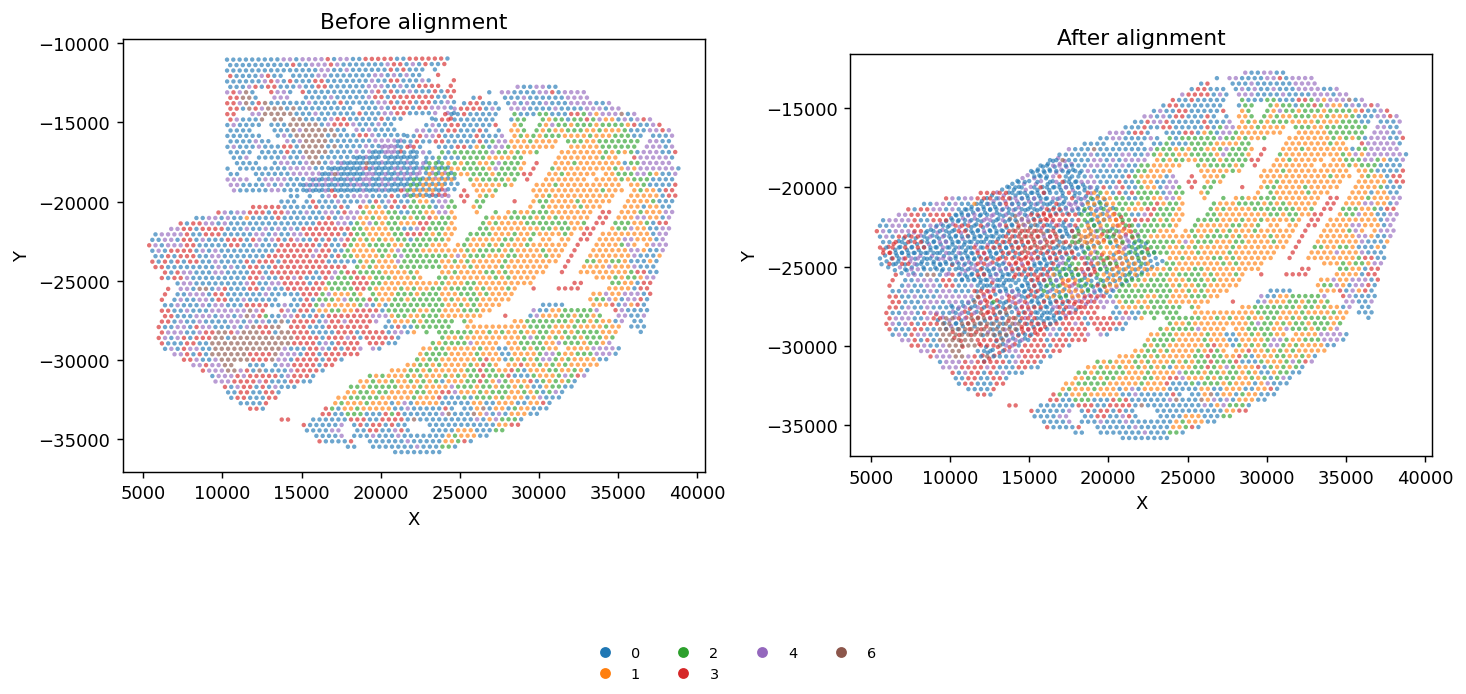

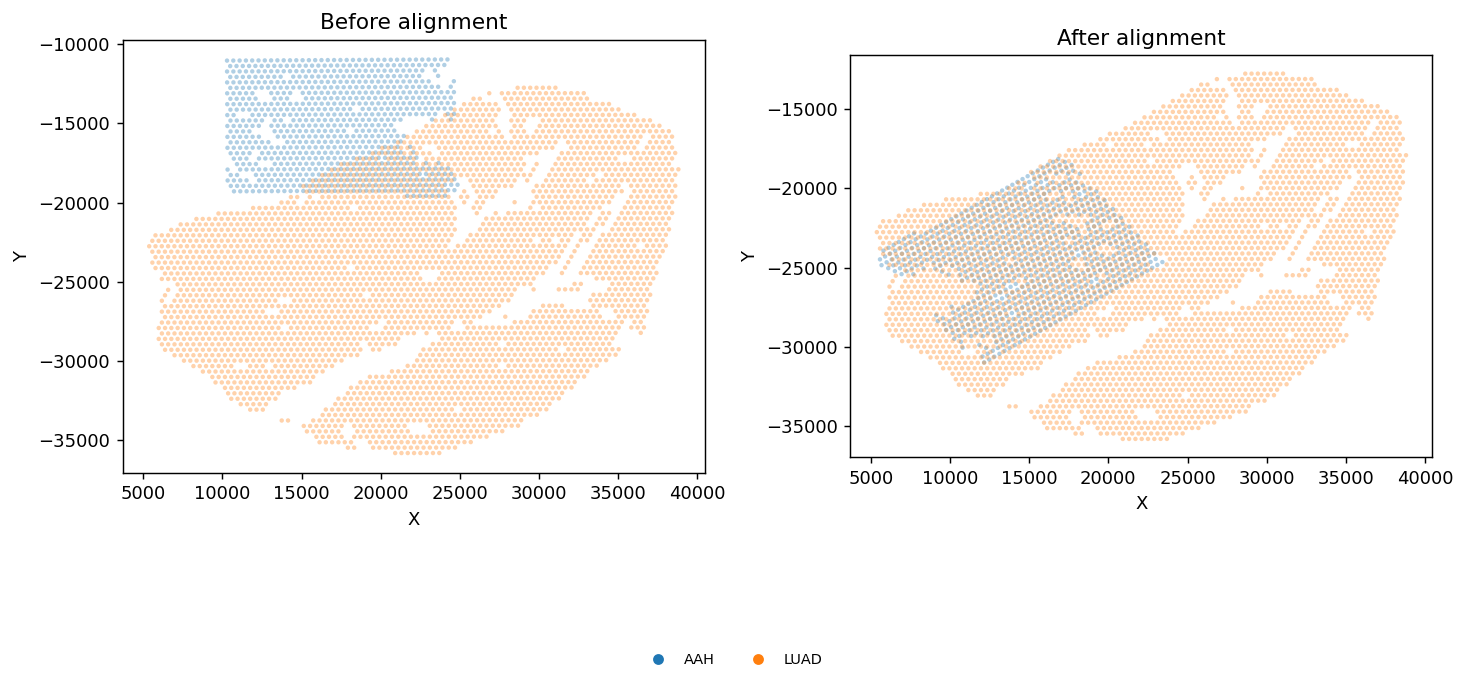

In [5]:
palette = annotation_palette(adata, '_clone_s', EXPERIMENT_DIR / "colors.json")
sample_panels(adata, spatial, 'status', '_clone_s', palette, title="Before alignment", dimension=2, flip_y=True, size=6);
sample_panels(adata, adata.obsm["spatial_aligned"], 'status', '_clone_s', palette, title="After alignment", dimension=2, flip_y=True, size=6);
alignment_overlay(adata, spatial, adata.obsm["spatial_aligned"], 'status', '_clone_s', palette, dimension=2, flip_y=True, size=6);
alignment_overlay(adata, spatial, adata.obsm["spatial_aligned"], 'status', '_clone_s', palette, dimension=2, flip_y=True, size=6, by_sample=True);


## Save input


In [6]:
model.save(SCANVI_DIR, overwrite=True, save_anndata=True)
adata.write_h5ad(SCANVI_ADATA, compression="gzip")
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")


Saved model-ready AnnData: /home/zhouyj/stVirtual_tutorial/experiments/human_lung_cancer/artifacts/checkpoints/scanvi/adata.h5ad


In [7]:
check = ad.read_h5ad(SCANVI_ADATA, backed="r")
try:
    summary = {
        "shape": check.shape,
        "statuses": check.obs["status"].astype(str).value_counts().to_dict(),
        "latent_shape": tuple(check.obsm[LATENT_KEY].shape),
        "counts_shape": tuple(check.layers["counts"].shape),
        "aligned_coordinates": all(key in check.obs for key in ("cx_aligned", "cy_aligned")),
    }
finally:
    check.file.close()
summary


{'shape': (4280, 18085),
 'statuses': {'LUAD': 3474, 'AAH': 806},
 'latent_shape': (4280, 10),
 'counts_shape': (4280, 18085),
 'aligned_coordinates': True}